# Job Market Intelligence Analysis for Data Analyst Roles

**Problem Statement:**

The goal of this project is to analyze job postings for Data Analyst roles to identify in-demand skills, job locations, and hiring trends.
This analysis aims to help job seekers understand market requirements and assist companies in making data-driven hiring decisions.

## Objectives

- Identify the most in-demand skills for Data Analyst roles
- Analyze job distribution across locations
- Understand experience level requirements
- Provide insights to help job seekers improve their chances of getting hired

## Dataset Description

The dataset contains job postings for Data Analyst roles, including job title, company, location, job type, experience level, job summary, and required skills.

Source: Kaggle

In [3]:
import pandas as pd

df = pd.read_csv("postings.csv")
df.head()

,job_title,company,job_location,job_link,first_seen,search_city,search_country,job level,job_type,job_summary,job_skills
0,"Data Analyst-SQL, Tableau",Zortech Solutions,"Mountain View, CA",https://www.linkedin.com/jobs/data-analyst-jobs,2023-12-20,Bloomington,United States,Associate,Onsite,NaN,NaN
1,Market Research & Insights Analyst,Indiana University Foundation,"Bloomington, IN",https://www.linkedin.com/jobs/view/market-rese...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Company Description\nAre you a high-performer ...,"Data analysis, Market research, Survey develop..."
2,Business Systems Analyst `1,Cook Medical,"Bloomington, IN",https://www.linkedin.com/jobs/view/business-sy...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Overview\nThe Business Systems Analyst 1 perfo...,"Business Analysis, Technical Writing, Software..."
3,Senior VAT and Indirect Tax Analyst,Epic,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-vat-...,2023-12-20,Bloomington,United States,Mid senior,Onsite,We're looking for an experienced tax professio...,"Accounting, Finance, VAT/GST tax regimes, US a..."
4,Senior HRIS Analyst (Timekeeping and Payroll),Nordson Corporation,Greater Bloomington Area,https://www.linkedin.com/jobs/view/senior-hris...,2023-12-20,Bloomington,United States,Mid senior,Remote,Collaboration drives Nordson’s success as a ma...,"Workday HCM, UKG Dimensions, Ceridian Dayforce..."


## Data Understanding

Exploring the dataset structure, column names, and data types.

In [4]:
df.columns

Index(['job_title', 'company', 'job_location', 'job_link', 'first_seen',
       'search_city', 'search_country', 'job level', 'job_type', 'job_summary',
       'job_skills'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12894 entries, 0 to 12893
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   job_title       12894 non-null  object
 1   company         12894 non-null  object
 2   job_location    12894 non-null  object
 3   job_link        12894 non-null  object
 4   first_seen      12894 non-null  object
 5   search_city     12894 non-null  object
 6   search_country  12894 non-null  object
 7   job_level       12894 non-null  object
 8   job_type        12894 non-null  object
 9   job_summary     12851 non-null  object
 10  job_skills      12705 non-null  object
dtypes: object(11)
memory usage: 1.1+ MB


In [19]:
df.describe()

,job_title,company,job_location,job_link,first_seen,search_city,search_country,job_level,job_type,job_summary,job_skills
count,12894,12894,12894,12894,12894,12894,12894,12894,12894,12851,12894
unique,6797,5283,2446,12894,1,834,4,2,3,11163,12697
top,Business Analyst,ClearanceJobs,United States,https://www.linkedin.com/jobs/data-analyst-jobs,2023-12-20,Hollywood,United States,Mid senior,Onsite,We're looking for an experienced tax professio...,
freq,438,238,247,1,12894,150,10386,9691,6670,97,189


## Data Cleaning

Performed data cleaning to ensure consistency and accuracy. This includes:
- Removing duplicates
- Handling missing values
- Standardizing column names

In [12]:
df.isnull().sum()

job_title           0
company             0
job_location        0
job_link            0
first_seen          0
search_city         0
search_country      0
job_level           0
job_type            0
job_summary        43
job_skills        189
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [20]:
# Fill missing skills with empty string
df['job_skills'] = df['job_skills'].fillna("")

# Missing job_summary can be left as is for now

In [15]:
df.isnull().sum()

job_title          0
company            0
job_location       0
job_link           0
first_seen         0
search_city        0
search_country     0
job_level          0
job_type           0
job_summary       43
job_skills         0
dtype: int64

In [18]:
df.columns = df.columns.str.lower().str.replace(" ","_")
df.columns

Index(['job_title', 'company', 'job_location', 'job_link', 'first_seen',
       'search_city', 'search_country', 'job_level', 'job_type', 'job_summary',
       'job_skills'],
      dtype='object')

- The dataset contained minimal missing values.
- Missing values in the job_skills column were handled by replacing them with empty strings to allow further processing.
- No duplicate records were found in the dataset.

## Skills Processing

The job_skills column contains multiple skills in a single string format. To enable proper analysis, the data is cleaned and transformed into a structured format by splitting the skills, removing extra spaces, and standardizing them into lowercase.

In [21]:
df['skills_list'] = df['job_skills'].apply(
    lambda x: [skill.strip().lower() for skill in x.split(',') if skill != ""]
)

In [22]:
df[['job_skills', 'skills_list']].head()

,job_skills,skills_list
0,,[]
1,"Data analysis, Market research, Survey develop...","[data analysis, market research, survey develo..."
2,"Business Analysis, Technical Writing, Software...","[business analysis, technical writing, softwar..."
3,"Accounting, Finance, VAT/GST tax regimes, US a...","[accounting, finance, vat/gst tax regimes, us ..."
4,"Workday HCM, UKG Dimensions, Ceridian Dayforce...","[workday hcm, ukg dimensions, ceridian dayforc..."


In [23]:
skills_df = df.explode('skills_list')

In [24]:
skills_df.head()

,job_title,company,job_location,job_link,first_seen,search_city,search_country,job_level,job_type,job_summary,job_skills,skills_list
0,"Data Analyst-SQL, Tableau",Zortech Solutions,"Mountain View, CA",https://www.linkedin.com/jobs/data-analyst-jobs,2023-12-20,Bloomington,United States,Associate,Onsite,NaN,,NaN
1,Market Research & Insights Analyst,Indiana University Foundation,"Bloomington, IN",https://www.linkedin.com/jobs/view/market-rese...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Company Description\nAre you a high-performer ...,"Data analysis, Market research, Survey develop...",data analysis
1,Market Research & Insights Analyst,Indiana University Foundation,"Bloomington, IN",https://www.linkedin.com/jobs/view/market-rese...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Company Description\nAre you a high-performer ...,"Data analysis, Market research, Survey develop...",market research
1,Market Research & Insights Analyst,Indiana University Foundation,"Bloomington, IN",https://www.linkedin.com/jobs/view/market-rese...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Company Description\nAre you a high-performer ...,"Data analysis, Market research, Survey develop...",survey development
1,Market Research & Insights Analyst,Indiana University Foundation,"Bloomington, IN",https://www.linkedin.com/jobs/view/market-rese...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Company Description\nAre you a high-performer ...,"Data analysis, Market research, Survey develop...",analytical methods


The skills_list column was expanded using the explode function, creating a new row for each individual skill. This allows accurate counting and analysis of skill frequency across job postings.

## Top Skills Analysis

In this step, we analyze the most in-demand skills required for Data Analyst roles by calculating the frequency of each skill across all job postings.

In [25]:
top_skills = skills_df['skills_list'].value_counts().head(15)
top_skills

skills_list
data analysis            4690
sql                      4289
project management       2531
communication            2475
data visualization       2327
tableau                  2168
excel                    2155
python                   2144
power bi                 1749
business analysis        1623
reporting                1394
problem solving          1362
business intelligence    1246
r                        1218
communication skills     1213
Name: count, dtype: int64

In [26]:
top_skills_df = top_skills.reset_index()
top_skills_df.columns = ['skill', 'count']
top_skills_df

,skill,count
0,data analysis,4690
1,sql,4289
2,project management,2531
3,communication,2475
4,data visualization,2327
5,tableau,2168
6,excel,2155
7,python,2144
8,power bi,1749
9,business analysis,1623


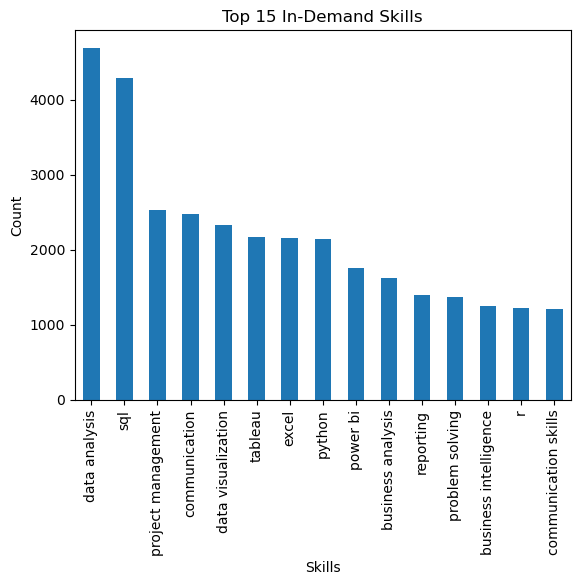

In [31]:
import matplotlib.pyplot as plt

top_skills.plot(kind='bar')
plt.title("Top 15 In-Demand Skills")
plt.xlabel("Skills")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()


### Insight

The analysis shows that SQL and data analysis are the most in-demand skills, making them essential for Data Analyst roles. Along with technical skills like Python, Excel, and Tableau, the demand for communication and problem-solving highlights the importance of both technical and business skills in the job market.

## Location Analysis

In this step, we analyze the distribution of job postings across different locations to identify key job hubs for Data Analyst roles.

In [32]:
top_location = df['job_location'].value_counts().head(10)
top_location

job_location
United States                         247
Chicago, IL                           143
New York, NY                          139
London, England, United Kingdom       136
Atlanta, GA                           121
Boston, MA                            113
Tampa, FL                             104
Richmond, VA                          104
Sydney, New South Wales, Australia     98
Washington, DC                         98
Name: count, dtype: int64

In [34]:
top_location_df = top_location.reset_index()
top_location_df.columns = ['location', 'count']
top_location_df

,location,count
0,United States,247
1,"Chicago, IL",143
2,"New York, NY",139
3,"London, England, United Kingdom",136
4,"Atlanta, GA",121
5,"Boston, MA",113
6,"Tampa, FL",104
7,"Richmond, VA",104
8,"Sydney, New South Wales, Australia",98
9,"Washington, DC",98


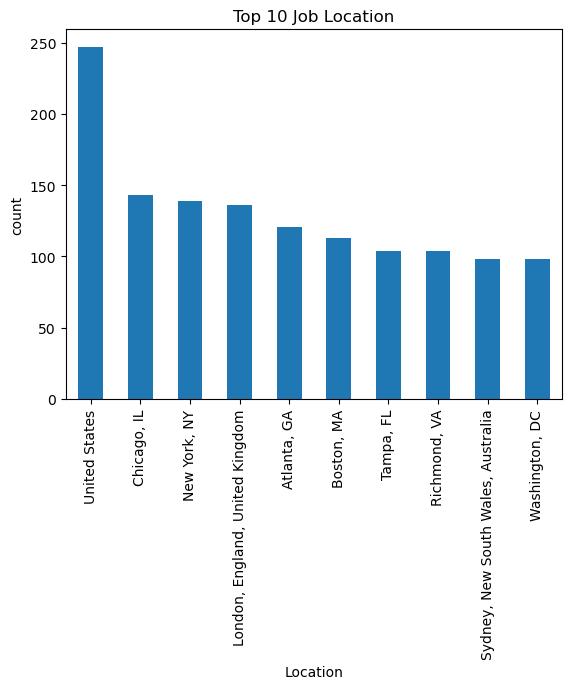

In [38]:
top_location.plot(kind='bar')

plt.title("Top 10 Job Location")
plt.xlabel("Location")
plt.ylabel("count")
plt.show()

### Insight

The analysis shows that the United States has the highest number of job postings, with major cities like Chicago, New York, and London also emerging as key hiring hubs. This indicates that job opportunities for Data Analysts are concentrated in developed urban regions with strong business and technology presence.

## Experience Level Analysis

In this step, we analyze the distribution of job postings based on experience level to understand the demand for entry-level, mid-level, and senior roles.

In [39]:
exp_levels = df['job_level'].value_counts()
exp_levels

job_level
Mid senior    9691
Associate     3203
Name: count, dtype: int64

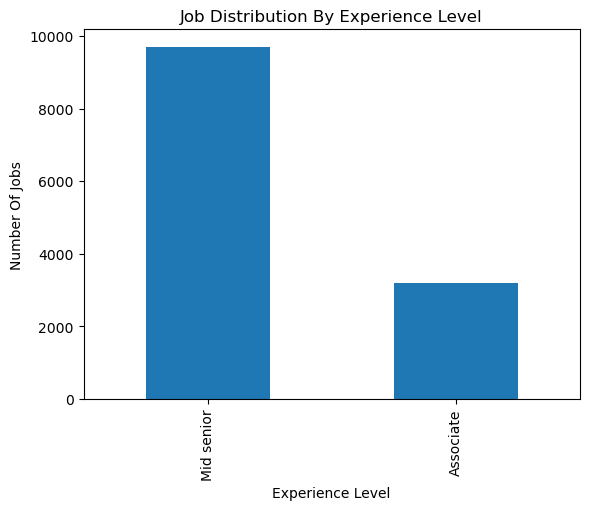

In [40]:
exp_levels.plot(kind='bar')
plt.title("Job Distribution By Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number Of Jobs")
plt.show()

### Insight

The analysis shows that most job opportunities are concentrated in mid-senior level roles, while associate-level positions are significantly fewer. This indicates that entry-level candidates may face higher competition and need strong skills to secure roles.

## Key Insights

- SQL and data analysis are the most in-demand skills, making them essential for Data Analyst roles.
- Technical skills like Python, Excel, and Tableau are highly valued, along with communication and problem-solving abilities.
- Job opportunities are concentrated in regions like the United States and major cities such as Chicago and New York.
- Most job postings are for mid-senior level roles, with fewer opportunities available for entry-level candidates.

## Recommendations

For Job Seekers:
- Focus on building strong skills in SQL and data analysis as they are highly in demand.
- Learn tools like Python, Excel, and Tableau to increase job opportunities.
- Develop communication and problem-solving skills to meet industry expectations.
- Target major job hubs such as the United States and key cities for better opportunities.

For Companies:
- Clearly define required skills in job postings to attract suitable candidates.
- Consider providing opportunities for entry-level candidates to build a strong talent pipeline.